In [31]:
import fitsio as fio
import numpy as np
import h5py as h5
import matplotlib
from matplotlib import pyplot as plt
import proplot as pplt
from tqdm import tqdm
import yaml
import io
from esutil.wcsutil import WCS
%matplotlib inline

In [37]:
d = h5.File('/global/cfs/cdirs/des/y6-shear-catalogs/Y6A2_METADETECT_V6_UNBLINDED/metadetect_cutsv6_all.h5','r')
x = np.array(d['/mdet/noshear/x'][:]); y = np.array(d['/mdet/noshear/y'][:])
slice_id = np.array(d['/mdet/noshear/slice_id'][:])
tilename = np.array(d['/mdet/noshear/tilename'][:]).astype('str')

In [32]:
f = '/global/cfs/cdirs/des/myamamot/DES0131-0250_r5933p01_pizza-cutter-info_r.yaml'
with open(f, 'r') as stream:
    data = yaml.safe_load(stream)
h = fio.read_header('/global/cfs/cdirs/des/myamamot/DES0131-0250_r4920p01_r.fits.fz', ext=1)
wcs = WCS(h)

f = '/global/cfs/cdirs/des/myamamot/DES0132-0333_r5933p01_pizza-cutter-info_r.yaml'
with open(f, 'r') as stream:
    data2 = yaml.safe_load(stream)
h2 = fio.read_header('/global/cfs/cdirs/des/myamamot/DES0132-0333_r4920p01_r.fits.fz', ext=1)
wcs2 = WCS(h2)

Text(0, 0.5, 'DES0132-0333')

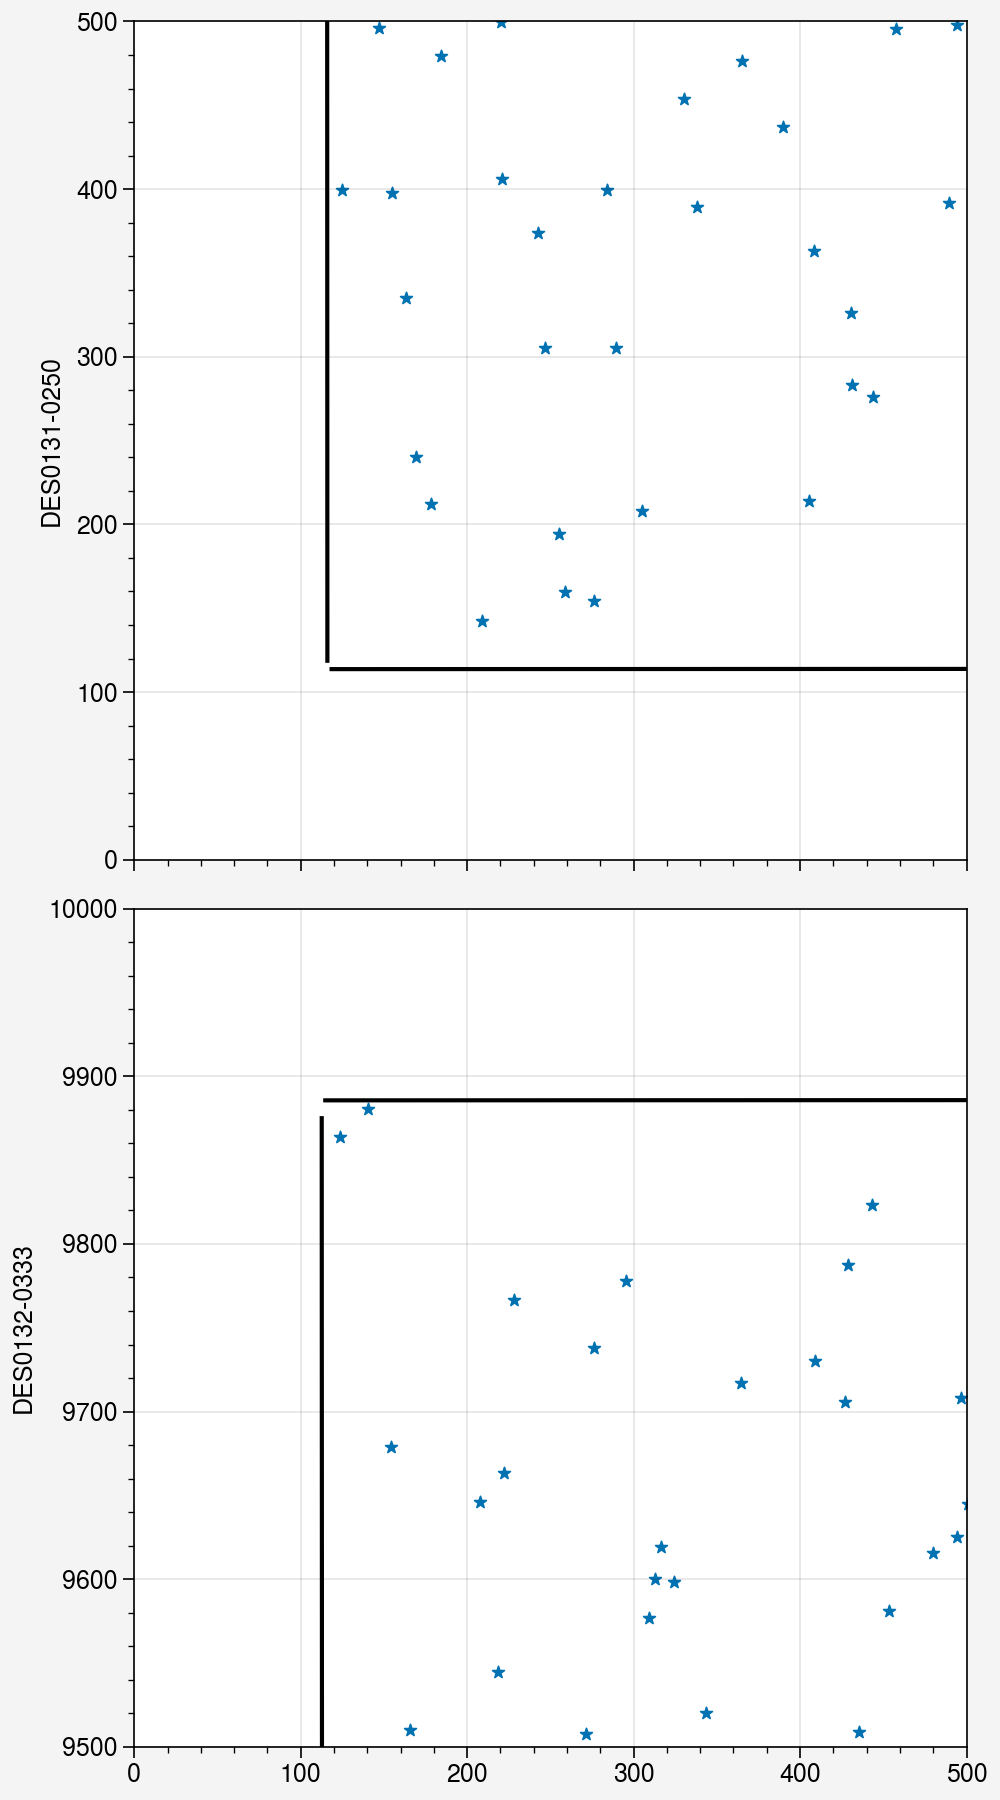

In [57]:
msk = (tilename == 'DES0131-0250')
msk2 = (tilename == 'DES0132-0333')
size = 50 + 98*100 + 25
fig,ax = pplt.subplots(figsize=(5,9),nrows=2,ncols=1,sharey=False)

# DES0131-0250
ramin, decmin = wcs.image2sky(0, 0)
ramax, decmax = wcs.image2sky(size, size)

decv = np.linspace(decmin, decmax, 1000)
decv = decv[decv > data["udecmin"]]
rav = np.linspace(ramin, ramax, 1000)
rav = rav[rav < data["uramax"]]

xb, yb = wcs.sky2image(data["uramax"], decv)
ax[0].plot(xb, yb, color="black")

xb, yb = wcs.sky2image(rav, data["udecmin"])
ax[0].plot(xb, yb, color="black")
ax[0].scatter(x[msk], y[msk], s=20, marker='*')
ax[0].set_xlim(0,500)
ax[0].set_ylim(0,500)
ax[0].set_ylabel('DES0131-0250')


# DES0132-0333
ramin, decmin = wcs2.image2sky(0, 0)
ramax, decmax = wcs2.image2sky(size, size)

decv = np.linspace(decmin, decmax, 1000)
decv = decv[decv > data2["udecmin"]]
rav = np.linspace(ramin, ramax, 1000)
rav = rav[rav < data2["uramax"]]

xb, yb = wcs2.sky2image(data2["uramax"], decv)
ax[1].plot(xb, yb, color="black")

xb, yb = wcs2.sky2image(rav, data2["udecmax"])
ax[1].plot(xb, yb, color="black")
ax[1].scatter(x[msk2], y[msk2], s=20, marker='*')
ax[1].set_xlim(0,500)
ax[1].set_ylim(9500,10000)
ax[1].set_ylabel('DES0132-0333')